<a href="https://colab.research.google.com/github/aqlaboratory/openfold-3/blob/main/examples/template_kinase_example_notebook/2026_of3_multistate_kinase_generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenFold3 Multistate for Kinases — CIF Direct Template Mode

Kinase-conformation–specific structure prediction with **OpenFold3** ([aqlaboratory/openfold-3](https://github.com/aqlaboratory/openfold-3)), using the **CIF Direct Template Mode** added in [PR #37](https://github.com/aqlaboratory/openfold-3/pull/37).

Stay tuned for a future AF2-specific Kinase notebook and preprint for citing! This notebook is a conceptual port of that approach.

DFG / conformational states follow [Modi & Dunbrack 2022, NAR](https://academic.oup.com/nar/article/50/D1/D654/6395339) and the [Kincore](http://dunbrack.fccc.edu/kincore/) classification.

## Pipeline

1. Pick a kinase sequence + target DFG state.
2. Download the **state-specific Kincore DB** (the `kinase100.<state>_a3m.ff{data,index}` files — Kincore's per-state list of chains that adopt that DFG conformation) and the shared mmCIF coordinate set.
3. Select templates from the state-filtered list. Three strategies are supported (chosen by `template_search_method` in Cell 2):
   - **local** (default, ~1 s): rank state-specific candidates locally by query↔template 4-mer overlap.
   - **all_in_state**: skip ranking; pass the first *N* state-specific CIFs to OpenFold3 and let CIF Direct Mode do `seq_identity × coverage` ranking internally.
   - **hhsearch_regen** (~30 s extra on first run): regenerate the missing `_cs219` files via `cstranslate` and run HHsearch exactly as AF2-multistate does.
   In all strategies the conformational filtering is preserved — we only ever look at templates from the chosen state's ffindex.
4. Pass the selected *(entry, chain)* pairs to OpenFold3 as `template_cif_paths` + `template_cif_chain_ids` (CIF Direct Mode, PR #37 — no separately precomputed alignment file required).
5. Run OpenFold3 inference (diffusion sampling) with the ColabFold MSA server for the input MSA.
6. Visualize models and confidence metrics.

## Why we don't run HHsearch by default

The Kincore OSF tarballs only ship `_a3m.ff{data,index}` — HHsearch's `_cs219` (prefilter) and `_hhm` (per-template HMMs) files are NOT included. A vanilla HHsearch call therefore crashes with `could not open file ..._cs219.ffdata`. The `local` strategy sidesteps this entirely; `hhsearch_regen` regenerates `_cs219` on the fly with `cstranslate` if you want a faithful AF2-multistate reproduction.

## Note on the ColabFold mmseqs2 server

The ColabFold mmseqs2 server is already used inside OpenFold3 inference for the *MSA* (via `--use-msa-server` in Cell 8) — you do not need to call it yourself. It is *not* a substitute for state-specific template selection (ColabFold returns PDB70 hits, not Kincore state-filtered hits), which is what this cell handles.

## GPU requirements

OpenFold3 inference requires **CUDA ≥ 12.1 and ≥ 32 GB GPU memory** (A100 40 GB recommended). On Colab, choose the **A100** runtime under *Runtime → Change runtime type*. T4/V100 will OOM at typical kinase lengths even with `low_mem` enabled.

## How this differs from the AF2 notebook

| AF2-multistate notebook                                  | This OpenFold3 notebook                                                  |
| -------------------------------------------------------- | ------------------------------------------------------------------------ |
| ColabFold + JAX/haiku pins                               | `pip install openfold3[cuequivariance]` + `setup_openfold`               |
| HHsearch ranks state-specific templates                  | Local k-mer ranking by default (HHsearch optional, see Cell 7)           |
| Templates passed to AF2 via HHsearch alignment (.hhr)    | Templates passed to OF3 via `template_cif_paths` (CIF Direct Mode)       |
| `colabfold_runner.run(...)` (Python API)                 | `run_openfold predict ...` (CLI)                                         |
| 5 model variants × 5 recycles                            | `num_diffusion_samples` × `num_model_seeds` (diffusion sampler)          |

Both pipelines use the **same Kincore state-specific template list** (`kinase100.<state>_a3m.ffindex`) as the source of conformationally-screened candidate chains, ensuring conformationally-equivalent template input to both models.


In [ ]:
#@title 0. Environment variables — run FIRST

import os, sys
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]   = "platform"
os.environ["TF_FORCE_UNIFIED_MEMORY"]       = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"]          = "2"
os.environ["OPENFOLD_CACHE"]                = os.path.expanduser("~/.openfold3")

# Capture THIS kernel's Python interpreter so the install cell's `pip` calls
# always land in the right site-packages, regardless of what's first on PATH.
# Without this, prepending /opt/conda/bin (for HH-suite) below would also
# make `pip install py3Dmol` resolve to Miniforge's pip (Python 3.13), while
# the kernel actually runs Python 3.12 at /usr/local/lib/. The Cell 9 viewer
# then fails with ModuleNotFoundError because py3Dmol is in the wrong env.
os.environ["KERNEL_PYTHON"] = sys.executable
print(f"Kernel Python:  {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")

# Make sure /opt/conda/bin (Miniforge's HH-suite/Kalign) and /usr/local/bin
# (where the install cell symlinks the conda binaries) are on PATH so
# subprocess.run("hhsearch", ...) etc. resolves. The KERNEL_PYTHON capture
# above protects pip-install commands from being hijacked by conda's pip.
_extra_paths = ["/opt/conda/bin", "/usr/local/bin"]
_existing    = os.environ.get("PATH", "").split(":")
for _p in reversed(_extra_paths):
    if _p not in _existing:
        os.environ["PATH"] = _p + ":" + os.environ["PATH"]

print("\nPATH now includes:")
for _p in _extra_paths:
    print(f"  {_p}  ({'on PATH' if _p in os.environ['PATH'].split(':') else 'MISSING'})")
print("\nNow run the input configuration cell.")


Kernel Python:  /usr/bin/python3
Python version: 3.12.13

PATH now includes:
  /opt/conda/bin  (on PATH)
  /usr/local/bin  (on PATH)

Now run the input configuration cell.


In [ ]:
#@title 1. Input configuration  { run: "auto", display-mode: "form" }

#@markdown ### Required
query_sequence = "ATQAVHEFAKELDATNISIDKVVGAGEFGEVCSGRLKLPSKKEISVAIKTLKVGYTEKQRRDFLGEASIMGQFDHPNIIRLEGVVTKSKPVMIVTEYMENGSLDSFLRKHDAQFTVIQLVGMLRGIASGMKYLSDMGYVHRDLAARNILINSNLVCKVSDFGLSRVLEDDPEAAYTTRGGKIPIRWTSPEAIAYRKFTSASDVWSYGIVLWEVMSYGERPYWEMSNQDVIKAVDEGYRLPPPMDCPAALYQLMLDCWQKDRNNRPKFEQIVSILDKLIRNPGSLKIITSAAARPSNLLLDQSNVDITTFRTTGDWLNGVWTAHCKEIFTGVEYSSCDT"  #@param {type:"string"}
jobname        = "EphA3_DFGin_BBAminus_OF3_MSA"  #@param {type:"string"}

#@markdown ### DFG conformational state (Modi & Dunbrack / Kincore)
kinase_state = "DFGout_BBAminus"  #@param ["DFGin_BLAminus", "DFGin_BLAplus", "DFGin_BLBminus", "DFGin_BLBplus", "DFGin_BLBtrans", "DFGin_ABAminus", "DFGin_All", "DFGin_Other", "DFGinter_BABtrans", "DFGinter_All", "DFGinter_Other", "DFGout_BBAminus", "DFGout_All", "DFGout_Other", "Other_All"]

#@markdown ### OpenFold3 sampling
num_diffusion_samples = 5    #@param [1, 2, 3, 5, 10] {type:"raw"}
num_model_seeds       = 1    #@param [1, 2, 3] {type:"raw"}

#@markdown ### Templates
num_templates  = 10   #@param [4, 8, 10, 15, 20] {type:"raw"}
#@markdown Template selection strategy (Kincore OSF DB ships only `_a3m.ff{data,index}` — HHsearch's `_cs219` and `_hhm` files are missing, so the original AF2-multistate HHsearch call fails out of the box):
#@markdown - **local** (default, fast): rank state-specific templates by query↔template 4-mer overlap in pure Python. Conformational filtering is preserved because we only look in the state-specific ffindex.
#@markdown - **all_in_state**: skip ranking entirely; pass the first N state-specific CIFs to OpenFold3 and let CIF Direct Mode rank by `seq_identity × coverage`.
#@markdown - **hhsearch_regen**: regenerate the missing `_cs219` files with `cstranslate` (~30 s) and run HHsearch. Matches AF2-multistate exactly but pays the rebuild cost on first run.
template_search_method = "local"  #@param ["local", "all_in_state", "hhsearch_regen"]

#@markdown ### MSA mode
#@markdown - **msa_server** (default): fetch MSA from ColabFold mmseqs2 server. Highest accuracy for monomer structure prediction but for kinases the MSA tends to encode the dominant *active* (BLAminus) conformation across the entire kinome, which can wash out the state-specific template signal.
#@markdown - **msa_free**: skip MSA generation. Diffusion is then dominated by template signal alone. Recommended if you find `msa_server` always returns the same conformation regardless of which Kincore state you pick.
msa_mode = "msa_free"  #@param ["msa_server", "msa_free"]
use_msa_server = (msa_mode == "msa_server")

#@markdown ### Memory / IO
use_low_mem          = False #@param {type:"boolean"}
save_to_google_drive = False #@param {type:"boolean"}

conformational_state = kinase_state

import re, pathlib
query_sequence = re.sub(r"[^A-Za-z]", "", query_sequence).upper()
jobname        = re.sub(r"[^A-Za-z0-9_\-]", "_", jobname)
assert len(query_sequence) >= 16, "Query too short."

pathlib.Path(jobname).mkdir(exist_ok=True)
print(f"Job: {jobname}  ({len(query_sequence)} aa, state={kinase_state})")
print(f"OF3 sampling: {num_diffusion_samples} diffusion samples × {num_model_seeds} seed(s)")
print(f"Templates: top {num_templates} from kinase100.{kinase_state}")


Job: EphA3_DFGin_BBAminus_OF3_MSA  (338 aa, state=DFGout_BBAminus)
OF3 sampling: 5 diffusion samples × 1 seed(s)
Templates: top 10 from kinase100.DFGout_BBAminus


In [ ]:
#@title 2. Install OpenFold3 + HH-suite + Kalign + viz deps
%%bash -s $use_low_mem

set -e

USE_LOW_MEM=$1

# --- [1/4] Install OpenFold3 from GitHub @ the PR #37 merge commit --------
# IMPORTANT: PyPI's `openfold3==0.4.1` predates PR #37 (CIF Direct Template
# Mode). Its InferenceExperimentConfig.template_preprocessor_settings does
# NOT accept `cif_direct_min_score`, so vanilla `pip install openfold3`
# crashes Cell 8 with a pydantic ValidationError. We pin to commit
#   5fbf72d744a627ba08a0cbe19da4f3149910c2b6
# which is the merge commit for PR #37 on main (merged 2026-05-26).
OF3_COMMIT="5fbf72d744a627ba08a0cbe19da4f3149910c2b6"
OF3_MARKER="OF3_INSTALLED_${OF3_COMMIT:0:8}"

if [ ! -f "${OF3_MARKER}" ]; then
  echo "[1/4] Installing OpenFold3 @ commit ${OF3_COMMIT:0:8} (PR #37 / CIF Direct Templates)..."
  echo "  Using KERNEL_PYTHON=${KERNEL_PYTHON}"
  # Clear any stale install markers from earlier PyPI-based runs
  rm -f OF3_INSTALLED OF3_INSTALLED_*
  # Remove any pre-existing openfold3 (e.g. stale PyPI version) so the
  # GitHub install actually takes effect even if version strings match.
  # Use the kernel's python explicitly so we don't accidentally uninstall
  # from Miniforge's Python after step [3/4] runs.
  "${KERNEL_PYTHON}" -m pip uninstall -y -q openfold3 openfold3-cuequivariance 2>&1 | tail -2 || true
  # Install from GitHub. cuequivariance extra unlocks GPU-accelerated kernels.
  "${KERNEL_PYTHON}" -m pip install -q "openfold3[cuequivariance] @ git+https://github.com/aqlaboratory/openfold-3.git@${OF3_COMMIT}" 2>&1 | tail -5 \
    || "${KERNEL_PYTHON}" -m pip install -q "git+https://github.com/aqlaboratory/openfold-3.git@${OF3_COMMIT}" 2>&1 | tail -5
  touch "${OF3_MARKER}"
fi

# --- [2/4] Download OpenFold3 model parameters -----------------------------
# setup_openfold is INTERACTIVE — it asks FOUR questions:
#   1. cache directory             (default: ~/.openfold3)
#   2. params directory            (default: ~/.openfold3)
#   3. which params to grab        (1 = default ckpt only, 2 = all, 3 = specific)
#   4. run integration tests       (yes/no)
# We pipe in "\n\n1\nno\n" so it accepts both default paths, downloads only
# the ~5 GB default checkpoint, and skips the (lengthy) integration tests.
# **Do not remove the printf** — without it, setup_openfold reads stdin from
# this bash script and consumes the next lines as answers, which silently
# skips the [3/4] HH-suite install and is what causes "hhsearch: No such
# file or directory" later in Cell 6.
WEIGHTS_DIR="${HOME}/.openfold3"
have_pt=$(find "${WEIGHTS_DIR}" -name '*.pt' 2>/dev/null | head -1)
if [ -z "${have_pt}" ]; then
  echo "[2/4] Downloading OpenFold3 model parameters (~5 GB, several minutes)..."
  printf '\n\n1\nno\n' | setup_openfold 2>&1 | tail -30 \
    || echo "  (setup_openfold exited non-zero — check above)"
  n_pt=$(find "${WEIGHTS_DIR}" -name '*.pt' 2>/dev/null | wc -l)
  if [ "${n_pt}" -eq 0 ]; then
    echo "  !!! WARNING: no .pt files in ${WEIGHTS_DIR} after setup_openfold."
    echo "      Cell 8 (inference) will fail. Re-run this cell, or run manually:"
    echo "        printf '\\n\\n1\\nno\\n' | setup_openfold"
  else
    echo "  OK: ${n_pt} .pt file(s) in ${WEIGHTS_DIR}"
  fi
else
  echo "[2/4] Weights already in ${WEIGHTS_DIR} (skipping setup_openfold)"
fi

# --- [3/4] Miniforge3 + HH-suite + Kalign ---------------------------------
# We keep stderr visible here (only stdout is silenced) so that any failure in
# `conda install` is loud — silent failures here are the #1 cause of cell 4
# (HHsearch) crashing with "hhsearch: No such file or directory".
if [ ! -f CONDA_READY ]; then
  echo "[3/4] Installing Miniforge3 + HH-suite + Kalign..."
  wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh
  bash Miniforge3-Linux-x86_64.sh -bfp /opt/conda > /dev/null
  rm -f Miniforge3-Linux-x86_64.sh
  /opt/conda/bin/conda config --set auto_update_conda false

  echo "  Installing hhsuite + kalign2 via conda (~1-2 min)..."
  /opt/conda/bin/conda install -y -q -c conda-forge -c bioconda \
      kalign2=2.04 hhsuite=3.3.0 > /dev/null

  echo "  Symlinking conda binaries → /usr/local/bin ..."
  for tool in hhsearch hhblits hhmake hhalign kalign reformat.pl ffindex_build ffindex_get; do
    if [ -e "/opt/conda/bin/${tool}" ]; then
      ln -sf "/opt/conda/bin/${tool}" "/usr/local/bin/${tool}"
    else
      echo "    !!! WARNING: /opt/conda/bin/${tool} does not exist — conda install probably failed for this tool"
    fi
  done

  # Hard-fail loudly if hhsearch is still missing, so the user catches it
  # here instead of later in cell 4.
  if [ ! -e /opt/conda/bin/hhsearch ]; then
    echo
    echo "ERROR: hhsearch was not installed by conda. Cell 4 will fail."
    echo "Try re-running this cell, or run manually:"
    echo "  /opt/conda/bin/conda install -y -c conda-forge -c bioconda hhsuite=3.3.0"
    exit 1
  fi
  touch CONDA_READY
fi

# --- [4/4] Visualization deps ---------------------------------------------
# Use ${KERNEL_PYTHON} -m pip so installs land in the SAME interpreter as
# the notebook kernel. By this point /opt/conda/bin is on PATH (from Cell 1
# + step [3/4]), so a bare `pip` would resolve to Miniforge's pip (Python
# 3.13) — but the Jupyter kernel runs Colab's Python (3.12). Without
# explicit interpreter, packages would land in /opt/conda/lib/python3.13/
# and Cell 9 would crash with `ModuleNotFoundError: No module named
# 'py3Dmol'` even though pip said the install succeeded.
echo "[4/4] Installing visualization deps into ${KERNEL_PYTHON}..."
"${KERNEL_PYTHON}" -m pip install -q py3Dmol biotite matplotlib
echo "  Importability check:"
"${KERNEL_PYTHON}" -c "import py3Dmol, biotite, matplotlib; print(f'    py3Dmol={getattr(py3Dmol, \"__version__\", \"installed\")}, biotite={biotite.__version__}, matplotlib={matplotlib.__version__}')"

echo
echo "=== Install summary ==="
which run_openfold || echo "run_openfold: NOT FOUND on PATH (may still be importable as a Python module)"
echo "hhsearch:    $(ls -l /opt/conda/bin/hhsearch 2>/dev/null || echo NOT FOUND in /opt/conda/bin)"
echo "kalign:      $(ls -l /opt/conda/bin/kalign 2>/dev/null   || echo NOT FOUND in /opt/conda/bin)"
echo "Install cell complete."


[1/4] Installing OpenFold3 @ commit 5fbf72d7 (PR #37 / CIF Direct Templates)...
  Using KERNEL_PYTHON=/usr/bin/python3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
[2/4] Downloading OpenFold3 model parameters (~5 GB, several minutes)...
Setting up OpenFold cache directory...
Please specify the OpenFold cache directory (default: /root/.openfold3): Downloading OpenFold3 parameters...
Please specify the directory for parameter download (default: /root/.openfold3): Parameters directory set to: /root/.openfold3
Path saved to: /root/.open

In [ ]:
#@title 2b. Verify install + GPU
#@markdown This cell **raises an exception** if any critical component (OF3 CLI,
#@markdown hhsearch, kalign, or downloaded weights) is missing — that way you
#@markdown catch a broken install here instead of in Cell 6 or Cell 8.

import subprocess, shutil, os, pathlib

errors = []

print("--- OpenFold3 CLI ---")
of3 = shutil.which("run_openfold")
print(f"  run_openfold: {of3 or 'NOT FOUND'}")
if of3:
    r = subprocess.run([of3, "--help"], capture_output=True, text=True, timeout=60)
    print("  (--help) first 6 lines:")
    for ln in r.stdout.splitlines()[:6]:
        print(f"    {ln}")
else:
    errors.append("run_openfold not on PATH — pip install in Cell 2 step [1/4] may have failed.")

print("\n--- HH-suite / Kalign ---")
# shutil.which uses os.environ['PATH']; Cell 0 prepended /opt/conda/bin so
# this should work even if /usr/local/bin/hhsearch symlink was never made.
for tool in ["hhsearch", "kalign"]:
    found = shutil.which(tool)
    # Fallback: check the conda location directly
    if found is None:
        for p in ("/opt/conda/bin", "/usr/local/bin"):
            if pathlib.Path(p, tool).exists():
                found = str(pathlib.Path(p, tool))
                break
    print(f"  {tool}: {found or 'NOT FOUND'}")
    if found is None:
        errors.append(
            f"{tool} not found — Cell 2 step [3/4] (Miniforge + hhsuite/kalign2) "
            "failed. The usual cause is setup_openfold consuming the install "
            "script's stdin in step [2/4]. Re-run Cell 2."
        )

print("\n--- GPU ---")
try:
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,memory.free,driver_version",
         "--format=csv,noheader"], text=True).strip()
    print(f"  {out}")
    mem_total_mb = int(out.split(",")[1].strip().split()[0])
    if mem_total_mb < 30000:
        print(f"  !!! WARNING: GPU has only {mem_total_mb} MB — OpenFold3 prefers ≥ 32 GB. "
              "Enable use_low_mem and/or expect possible OOM at this kinase length.")
except Exception as e:
    print(f"  nvidia-smi: {e}")

print("\n--- OpenFold3 weights cache ---")
cache_dir = pathlib.Path(os.environ.get("OPENFOLD_CACHE", os.path.expanduser("~/.openfold3")))
print(f"  {cache_dir}")
pt_files = sorted(cache_dir.rglob("*.pt")) if cache_dir.exists() else []
if pt_files:
    for p in pt_files[:5]:
        print(f"    {p.relative_to(cache_dir)}  ({p.stat().st_size/1e9:.2f} GB)")
else:
    print("  (no .pt files found)")
    errors.append(
        "OpenFold3 weights not downloaded — Cell 2 step [2/4] (setup_openfold) "
        "did not produce any .pt files in the cache directory. Re-run Cell 2."
    )

print("\n--- Python deps (viz + structure) ---")
for pkg in ("py3Dmol", "biotite", "matplotlib", "numpy"):
    try:
        mod = __import__(pkg)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  {pkg}: {ver}")
    except ImportError as e:
        print(f"  {pkg}: NOT INSTALLED ({e})")
        errors.append(f"{pkg} not importable — Cell 2 step [4/4] failed.")

print("\n--- Attention kernel backend (we use Triton, not DeepSpeed) ---")
try:
    import triton
    print(f"  triton: {triton.__version__}  (used for OF3 evoformer attention)")
except ImportError as e:
    print(f"  triton: NOT INSTALLED ({e})")
    errors.append(
        "triton not importable — required because runner.yml sets "
        "use_triton_triangle_kernels=true (DeepSpeed4Science is too fragile "
        "to install on Colab). On Colab A100, triton normally ships with "
        "PyTorch; if missing, run: !pip install triton"
    )

print("\n--- OpenFold3 version (must include PR #37 / CIF Direct Templates) ---")
try:
    import openfold3
    of3_file = pathlib.Path(openfold3.__file__).parent
    of3_ver  = getattr(openfold3, "__version__", "?")
    print(f"  version:  {of3_ver}")
    print(f"  location: {of3_file}")
    # Inspect the pydantic config to verify the cif_direct fields landed.
    cfg_file = of3_file / "core" / "data" / "pipelines" / "preprocessing" / "template.py"
    if cfg_file.exists():
        has_cif_direct = "cif_direct_min_score" in cfg_file.read_text()
        print(f"  PR #37 CIF Direct fields present: {has_cif_direct}")
        if not has_cif_direct:
            errors.append(
                "Installed OpenFold3 lacks `cif_direct_min_score` — this is the "
                "PyPI 0.4.1 release, which predates PR #37. Re-run Cell 2; the "
                "new install command pins to the GitHub merge commit for PR #37."
            )
    else:
        # If the file moved, we'll catch it via the inference-time error.
        print(f"  (could not locate {cfg_file.name} to verify PR #37 fields)")
except ImportError as e:
    errors.append(f"openfold3 not importable: {e}")

print("\n--- Result ---")
if errors:
    print("FAILED:")
    for e in errors:
        print(f"  • {e}")
    raise RuntimeError(
        f"{len(errors)} install verification error(s) — see above. "
        "Re-run Cell 2 (Install) and check its output for the first failing step."
    )
print("OK — all components present.")


--- OpenFold3 CLI ---
  run_openfold: /usr/local/bin/run_openfold
  (--help) first 6 lines:
    Usage: run_openfold [OPTIONS] COMMAND [ARGS]...
    
    Options:
      --help  Show this message and exit.
    
    Commands:

--- HH-suite / Kalign ---
  hhsearch: /opt/conda/bin/hhsearch
  kalign: /opt/conda/bin/kalign

--- GPU ---
  NVIDIA A100-SXM4-40GB, 40960 MiB, 40442 MiB, 580.82.07

--- OpenFold3 weights cache ---
  /root/.openfold3
    of3-p2-155k.pt  (2.29 GB)

--- Python deps (viz + structure) ---
  py3Dmol: 2.5.5
  biotite: 1.6.0
  matplotlib: 3.10.0
  numpy: 2.0.2

--- Attention kernel backend (we use Triton, not DeepSpeed) ---
  triton: 3.6.0  (used for OF3 evoformer attention)

--- OpenFold3 version (must include PR #37 / CIF Direct Templates) ---
  version:  ?
  location: /usr/local/lib/python3.12/dist-packages/openfold3
  PR #37 CIF Direct fields present: True

--- Result ---
OK — all components present.


In [ ]:
#@title 3. Download Kincore HHsearch DB (state-specific) + shared mmCIF coordinates

import pathlib, subprocess, sys

# Same OSF URLs huhlim's AF2-multistate notebook uses (kinase100 DBs from
# Kincore, redistributed because the Zenodo mirror has been flaky).
KINASE100_OSF = {
    "DFGin_ABAminus":    "https://osf.io/97et8/download",
    "DFGin_All":         "https://osf.io/gx2m9/download",
    "DFGin_BLAminus":    "https://osf.io/s5749/download",
    "DFGin_BLAplus":     "https://osf.io/8gfu7/download",
    "DFGin_BLBminus":    "https://osf.io/xp6d3/download",
    "DFGin_BLBplus":     "https://osf.io/57k6g/download",
    "DFGin_BLBtrans":    "https://osf.io/r25gf/download",
    "DFGin_Other":       "https://osf.io/mekq7/download",
    "DFGinter_All":      "https://osf.io/te6uf/download",
    "DFGinter_BABtrans": "https://osf.io/uv4rd/download",
    "DFGinter_Other":    "https://osf.io/q5kpy/download",
    "DFGout_All":        "https://osf.io/yd7uh/download",
    "DFGout_BBAminus":   "https://osf.io/d4q9t/download",
    "DFGout_Other":      "https://osf.io/e324m/download",
    "Other_All":         "https://osf.io/6mq2e/download",
}
CIF_KINASE_OSF = "https://osf.io/gkzas/download"

db_home    = pathlib.Path("kinase100")
mmcif_home = db_home / "cif"
db_home.mkdir(exist_ok=True)

assert conformational_state in KINASE100_OSF, f"Unknown state: {conformational_state}"

def _fetch(url, out_path, what):
    print(f"Fetching {what} ...")
    r = subprocess.run(["wget", "-q", "-c", "-L", url, "-O", out_path], check=False)
    p = pathlib.Path(out_path)
    if r.returncode != 0 or not p.exists() or p.stat().st_size < 1_000_000:
        sys.exit(f"OSF download failed for {what} → {url}")
    print(f"  → {p.stat().st_size/1e6:.1f} MB")

# State-specific HHsearch DB
hh_tgz = f"kinase100.{conformational_state}.tgz"
hh_dir = db_home / f"kinase100.{conformational_state}"
if not hh_dir.exists():
    _fetch(KINASE100_OSF[conformational_state], hh_tgz, hh_tgz)
    subprocess.run(["tar", "xzf", hh_tgz, "-C", str(db_home)], check=True)
    pathlib.Path(hh_tgz).unlink()
    print(f"  → unpacked to {hh_dir}")

# Shared mmCIF coordinates (~3500 PDB entries, contains every chain referenced by any state DB)
cif_tgz = "cif.kinase.tgz"
if not mmcif_home.exists() or not any(mmcif_home.glob("*.cif")):
    _fetch(CIF_KINASE_OSF, cif_tgz, cif_tgz)
    subprocess.run(["tar", "xzf", cif_tgz, "-C", str(db_home)], check=True)
    pathlib.Path(cif_tgz).unlink()
    if not mmcif_home.exists() or not any(mmcif_home.glob("*.cif")):
        mmcif_home.mkdir(exist_ok=True)
        for c in db_home.rglob("*.cif"):
            if c.parent != mmcif_home:
                c.rename(mmcif_home / c.name)

ffindex = hh_dir / f"kinase100.{conformational_state}_a3m.ffindex"
n_cif   = len(list(mmcif_home.glob("*.cif")))
assert n_cif > 0, f"No mmCIFs in {mmcif_home}"
print(f"\nDB ready:")
print(f"  HHsearch DB: {hh_dir}")
print(f"  CIF library: {mmcif_home} ({n_cif} CIF files)")


Fetching kinase100.DFGout_BBAminus.tgz ...
  → 114.8 MB
  → unpacked to kinase100/kinase100.DFGout_BBAminus

DB ready:
  HHsearch DB: kinase100/kinase100.DFGout_BBAminus
  CIF library: kinase100/cif (5874 CIF files)


In [ ]:
#@title 4. Select state-specific templates (local rank / all-in-state / HHsearch-regen)
#
# Why this cell is not just "run HHsearch": the Kincore OSF tarballs we
# downloaded only contain `kinase100.<state>_a3m.ff{data,index}`. They do NOT
# contain the `_cs219.ff{data,index}` files (HHsearch's prefilter DB) or
# `_hhm.ff{data,index}` files (per-template HMMs). A naive HHsearch call
# crashes with "could not open file ..._cs219.ffdata".
#
# Three strategies, selected by `template_search_method` in Cell 2:
#
#   local           — (default, few seconds) rank state-specific templates
#                      by 4-mer overlap between the query and the CHAIN
#                      sequence extracted from each CIF file. We read the
#                      sequences from the CIFs (canonical, unambiguous) rather
#                      than from _a3m.ffdata (Kincore's blocks have a non-
#                      standard layout that yields garbage if parsed naively).
#   all_in_state    — skip ranking; take the first N state-specific IDs and
#                      let OpenFold3's CIF Direct Mode rank them by
#                      seq_identity × coverage.
#   hhsearch_regen  — regenerate _cs219 with `cstranslate` (~30 s) and run
#                      HHsearch. Matches AF2-multistate exactly.

import subprocess, re, pathlib, sys, shutil, os, time

# --- 4.0 locate ffindex (Kincore tarballs are inconsistent — sometimes
# nested under kinase100/kinase100.<state>/, sometimes flat under kinase100/).
state = conformational_state
candidates_index = [
    pathlib.Path(f"kinase100/kinase100.{state}/kinase100.{state}_a3m.ffindex"),
    pathlib.Path(f"kinase100/kinase100.{state}_a3m.ffindex"),
]
ffindex = next((p for p in candidates_index if p.exists()), None)
if ffindex is None:
    hits = list(pathlib.Path("kinase100").rglob(f"kinase100.{state}_a3m.ffindex"))
    if hits:
        ffindex = hits[0]
if ffindex is None:
    raise FileNotFoundError(
        f"Could not find kinase100.{state}_a3m.ffindex anywhere under kinase100/. "
        "Re-run Cell 5 (download Kincore DB)."
    )
ffdata  = ffindex.with_name(ffindex.name.replace(".ffindex", ".ffdata"))
cif_dir = pathlib.Path("kinase100/cif").resolve()
print(f"ffindex: {ffindex}")
print(f"ffdata:  {ffdata}  ({'present' if ffdata.exists() else 'MISSING'})")
print(f"CIFs:    {cif_dir}  ({len(list(cif_dir.glob('*.cif')))} files)")

# --- 4.1 parse ffindex → state-specific (entry, chain) IDs -----------------
# Kincore ffindex entry names look like "1BLX_A.a3m" (note the .a3m suffix —
# my earlier code's regex missed this and dropped every hit). Strip it.
def normalize_tid(raw):
    return pathlib.Path(raw).stem  # "1BLX_A.a3m" → "1BLX_A"

raw_entries = []
with open(ffindex) as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 3:
            raw_entries.append(parts[0])

# Map each ID → (cif_path, chain). Drop entries with no matching CIF.
ID_RE = re.compile(r"^([0-9A-Za-z]{4,5})_([A-Za-z0-9]+)$")
candidates = []  # [(tid, cif_path, chain), ...]
unparsed = no_cif = 0
for raw in raw_entries:
    tid = normalize_tid(raw)
    m = ID_RE.match(tid)
    if not m:
        unparsed += 1
        continue
    entry, chain = m.group(1), m.group(2)
    cif_file = None
    for cand_name in (f"{entry.lower()}.cif", f"{entry}.cif", f"{entry.upper()}.cif"):
        if (cif_dir / cand_name).exists():
            cif_file = cif_dir / cand_name
            break
    if cif_file is None:
        no_cif += 1
        continue
    candidates.append((tid, str(cif_file), chain))

print(f"\nState {state}: {len(raw_entries)} ffindex entries → "
      f"{len(candidates)} with available CIF "
      f"(skipped {unparsed} unparseable IDs, {no_cif} with no CIF)")

# --- helpers ----------------------------------------------------------------
# Extract a polymer sequence from a CIF by finding the longest \n;...;\n block
# whose contents are >80% standard amino acids. This is the PDB-deposited
# canonical sequence — what we want for ranking.

def quick_cif_sequence(cif_path):
    """Return the longest standard-protein sequence in any \n;...;\n block.
    CIF stores multi-line values (like entity_poly sequences) as
        \n;<content>\n;
    where <content> can span many lines. We scan all such blocks, keep ones
    that are >80% standard amino acids, and return the longest."""
    try:
        text = pathlib.Path(cif_path).read_text(errors="ignore")
    except Exception:
        return ""

    best = ""
    for m in re.finditer(r"\n;(.*?)\n;", text, re.DOTALL):
        seq = re.sub(r"[^A-Za-z]", "", m.group(1)).upper()
        if not seq:
            continue
        std_count = sum(1 for c in seq if c in "ACDEFGHIKLMNPQRSTVWY")
        if std_count / max(len(seq), 1) > 0.8 and len(seq) > len(best):
            best = seq
    return best

def kmer_overlap(q_kmers, t_seq, k=4):
    if len(t_seq) < k:
        return 0.0
    t_kmers = set(t_seq[i:i+k] for i in range(len(t_seq) - k + 1))
    return len(q_kmers & t_kmers) / max(len(q_kmers), 1)

selected = []  # final list of (tid, cif_path, chain) triples

# ============================================================================
# Strategy 1: local k-mer ranking (sequence from CIF, NOT from ffdata)
# ============================================================================
if template_search_method == "local":
    t0 = time.time()
    q_kmers = set(query_sequence[i:i+4] for i in range(len(query_sequence) - 3))
    print(f"\n[local] ranking {len(candidates)} templates by 4-mer overlap to query "
          f"({len(q_kmers)} unique 4-mers); reading sequences from CIFs...")

    scored = []
    skipped = 0
    seen_cif = set()  # one CIF per ranking — CIF often appears once per chain
    for tid, cif_path, chain in candidates:
        # Cache the sequence per CIF file (different chains in same CIF share
        # the entity_poly sequence if homomeric; for our score we use the
        # longest entity_poly which is a fine kinase-domain proxy).
        if cif_path in seen_cif:
            seq = seen_cif_seq[cif_path]
        else:
            seq = quick_cif_sequence(cif_path)
            seen_cif.add(cif_path)
            try: seen_cif_seq[cif_path] = seq
            except NameError:
                seen_cif_seq = {cif_path: seq}
        if not seq:
            skipped += 1
            continue
        scored.append((tid, cif_path, chain, kmer_overlap(q_kmers, seq), len(seq)))
    scored.sort(key=lambda x: -x[3])

    # Note on score magnitude: 4-mer overlap between two homologous kinases
    # is typically 0.02-0.10 (close family) and 0.005-0.02 (distant family).
    # Absolute values look small but the RANKING is what matters here — closer
    # homologs land at the top, which is exactly what we want for templates.
    print(f"\nTop {num_templates} state-specific templates:")
    print(f"  {'rank':>4s}  {'template':<10s}  {'kmer':>6s}  {'len':>5s}")
    for i, (tid, cif_path, chain, score, slen) in enumerate(scored[:num_templates], 1):
        print(f"  {i:>4d}  {tid:<10s}  {score:>6.3f}  {slen:>5d}")
        selected.append((tid, cif_path, chain))
    print(f"\n(ranking took {time.time()-t0:.1f}s; scored {len(scored)}, "
          f"skipped {skipped} CIFs with no parseable sequence)")

    if scored and all(s[3] < 0.001 for s in scored[:10]):
        print("\n!!! All top scores < 0.001 — sequence extraction may be broken on these files.")
        print(f"    Try template_search_method='all_in_state' instead.")
        print(f"    Debug: head of {candidates[0][1]}:")
        print("    " + pathlib.Path(candidates[0][1]).read_text(errors="ignore")[:400].replace("\n", "\n    "))

# ============================================================================
# Strategy 2: all-in-state (no ranking)
# ============================================================================
elif template_search_method == "all_in_state":
    print(f"\n[all_in_state] taking first {num_templates} state-specific templates "
          "(OpenFold3 CIF Direct Mode will rank by seq_identity × coverage)")
    for tid, cif_path, chain in candidates[:num_templates]:
        selected.append((tid, cif_path, chain))
        print(f"  {tid}")

# ============================================================================
# Strategy 3: HHsearch with cstranslate-based regeneration
# ============================================================================
elif template_search_method == "hhsearch_regen":
    if not ffdata.exists():
        raise FileNotFoundError(
            f"{ffdata} is required for hhsearch_regen but is missing. Switch to 'local' or 'all_in_state'."
        )

    # The hhsearch -d prefix is the ffindex path WITHOUT the _a3m.ffindex
    # suffix (i.e. it's the file basename without "_a3m.ff{data,index}").
    db_prefix = ffindex.with_name(ffindex.name.replace("_a3m.ffindex", ""))
    cs219_data = db_prefix.parent / (db_prefix.name + "_cs219.ffdata")
    print(f"[hhsearch_regen] db prefix: {db_prefix}")

    # Locate cs219.lib + context_data.lib (ship with HH-suite)
    hhsuite_data = None
    for cand in ["/opt/conda/share/hhsuite/data",
                 "/opt/conda/share/hhsuite-3.3.0/data",
                 "/usr/share/hhsuite/data"]:
        if pathlib.Path(cand, "cs219.lib").exists():
            hhsuite_data = pathlib.Path(cand); break
    if hhsuite_data is None:
        for p in pathlib.Path("/opt/conda").rglob("cs219.lib"):
            hhsuite_data = p.parent; break
    if hhsuite_data is None:
        raise FileNotFoundError("Could not find cs219.lib (HH-suite data dir).")
    print(f"  hhsuite data: {hhsuite_data}")

    cstranslate = shutil.which("cstranslate") or "/opt/conda/bin/cstranslate"
    hhsearch    = shutil.which("hhsearch")    or "/opt/conda/bin/hhsearch"

    if not cs219_data.exists():
        print(f"\n  Regenerating _cs219 via cstranslate (~30 s)...")
        r = subprocess.run([
            cstranslate,
            "-A", str(hhsuite_data / "cs219.lib"),
            "-D", str(hhsuite_data / "context_data.lib"),
            "-x", "0.3", "-c", "4", "-I", "a3m", "-f",
            "-i", str(db_prefix),
            "-o", str(db_prefix.parent / (db_prefix.name + "_cs219")),
        ], capture_output=True, text=True)
        if r.returncode != 0:
            print(r.stdout[-1000:]); print(r.stderr[-1000:])
            raise RuntimeError("cstranslate failed; switch to template_search_method='local'.")
        print(f"  → {cs219_data}  ({cs219_data.stat().st_size/1e6:.1f} MB)")

    query_a3m = pathlib.Path(jobname) / f"{jobname}_query.a3m"
    query_a3m.write_text(f">{jobname}\n{query_sequence}\n")
    hhr_path = pathlib.Path(jobname) / f"{jobname}_templates.hhr"

    print(f"\n  Running HHsearch ...")
    r = subprocess.run([
        hhsearch,
        "-i", str(query_a3m),
        "-o", str(hhr_path),
        "-maxseq", "1000000",
        "-d", str(db_prefix),
    ], capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-1500:]); print(r.stderr[-1500:])
        raise RuntimeError("HHsearch failed; switch to 'local' or 'all_in_state'.")

    # Parse top N hits; cross-reference against `candidates` dict
    cand_by_id = {tid: (tid, cp, ch) for (tid, cp, ch) in candidates}
    print(f"\nTop HHsearch hits:")
    print(f"  {'rank':>4s}  {'template':<10s}  {'prob':>6s}  {'E-value':>10s}")
    with open(hhr_path) as f:
        in_table = False
        for line in f:
            if line.startswith(" No Hit"):
                in_table = True; continue
            if in_table:
                if not line.strip(): break
                m = re.match(r"\s*\d+\s+(\S+)\s+(\d+\.\d+)\s+(\S+)", line)
                if m and len(selected) < num_templates:
                    hit_tid = normalize_tid(m.group(1))
                    if hit_tid in cand_by_id:
                        selected.append(cand_by_id[hit_tid])
                        print(f"  {len(selected):>4d}  {hit_tid:<10s}  "
                              f"{float(m.group(2)):>6.1f}  {m.group(3):>10s}")

else:
    raise ValueError(f"Unknown template_search_method: {template_search_method!r}")

# --- 4.2 emit template_cif_paths + template_cif_chain_ids ------------------
template_cif_paths     = [t[1] for t in selected]
template_cif_chain_ids = [t[2] for t in selected]

if not template_cif_paths:
    raise RuntimeError(
        f"No templates selected for state {state}. "
        "Try template_search_method='all_in_state' as a fallback."
    )

print(f"\n{len(template_cif_paths)} (entry, chain) templates resolved → OpenFold3.")
for tid, p, c in selected:
    print(f"  {tid:<10s} → {pathlib.Path(p).name} chain {c}")


ffindex: kinase100/kinase100.DFGout_BBAminus_a3m.ffindex
ffdata:  kinase100/kinase100.DFGout_BBAminus_a3m.ffdata  (present)
CIFs:    /content/kinase100/cif  (5874 files)

State DFGout_BBAminus: 262 ffindex entries → 262 with available CIF (skipped 0 unparseable IDs, 0 with no CIF)

[local] ranking 262 templates by 4-mer overlap to query (335 unique 4-mers); reading sequences from CIFs...

Top 10 state-specific templates:
  rank  template      kmer    len
     1  3DZQ_A       0.988    361
     2  3DKO_A       0.424    318
     3  6FNJ_A       0.337    297
     4  6HEX_A       0.293    306
     5  6Q7B_A       0.293    306
     6  6Q7D_A       0.293    306
     7  3F3U_A       0.066    286
     8  3OEZ_A       0.066    286
     9  3TZ7_A       0.066    286
    10  3TZ8_B       0.066    286

(ranking took 0.2s; scored 262, skipped 0 CIFs with no parseable sequence)

10 (entry, chain) templates resolved → OpenFold3.
  3DZQ_A     → 3dzq.cif chain A
  3DKO_A     → 3dko.cif chain A
  6FNJ_A  

In [ ]:
#@title 5. Build OpenFold3 query JSON

import json, pathlib

# OpenFold3 query format (see docs/source/input_format_reference.md):
#   queries.<jobname>.chains[i] is one chain definition. For CIF Direct
#   Template Mode (PR #37), we set template_cif_paths to a list of CIF files
#   and template_cif_chain_ids to the matching chain IDs. OpenFold3 then aligns
#   each (cif, chain) sequence to the query, scores by seq_identity × coverage,
#   and uses the qualifying ones as templates without needing an alignment file.
#
# Mutual exclusivity (from PR #37):
#   template_cif_paths    is exclusive with template_alignment_file_path.
#   Here we exclusively use the CIF direct path.

query_dict = {
    "queries": {
        jobname: {
            "chains": [
                {
                    "molecule_type":          "protein",
                    "chain_ids":              ["A"],
                    "sequence":               query_sequence,
                    "template_cif_paths":     template_cif_paths,
                    "template_cif_chain_ids": template_cif_chain_ids,
                }
            ]
        }
    }
}

query_json_path = pathlib.Path(jobname) / f"{jobname}_query.json"
with open(query_json_path, "w") as f:
    json.dump(query_dict, f, indent=2)

print(f"Wrote query JSON: {query_json_path}\n")
preview = json.dumps(query_dict, indent=2)
print(preview if len(preview) < 2000 else preview[:2000] + "\n  ...(truncated)")


Wrote query JSON: EphA3_DFGin_BBAminus_OF3_MSA/EphA3_DFGin_BBAminus_OF3_MSA_query.json

{
  "queries": {
    "EphA3_DFGin_BBAminus_OF3_MSA": {
      "chains": [
        {
          "molecule_type": "protein",
          "chain_ids": [
            "A"
          ],
          "sequence": "ATQAVHEFAKELDATNISIDKVVGAGEFGEVCSGRLKLPSKKEISVAIKTLKVGYTEKQRRDFLGEASIMGQFDHPNIIRLEGVVTKSKPVMIVTEYMENGSLDSFLRKHDAQFTVIQLVGMLRGIASGMKYLSDMGYVHRDLAARNILINSNLVCKVSDFGLSRVLEDDPEAAYTTRGGKIPIRWTSPEAIAYRKFTSASDVWSYGIVLWEVMSYGERPYWEMSNQDVIKAVDEGYRLPPPMDCPAALYQLMLDCWQKDRNNRPKFEQIVSILDKLIRNPGSLKIITSAAARPSNLLLDQSNVDITTFRTTGDWLNGVWTAHCKEIFTGVEYSSCDT",
          "template_cif_paths": [
            "/content/kinase100/cif/3dzq.cif",
            "/content/kinase100/cif/3dko.cif",
            "/content/kinase100/cif/6fnj.cif",
            "/content/kinase100/cif/6hex.cif",
            "/content/kinase100/cif/6q7b.cif",
            "/content/kinase100/cif/6q7d.cif",
            "/content/kinase100/cif/3f3u.cif",
          

In [ ]:
#@title 6. Run OpenFold3 inference

import subprocess, sys, pathlib, time, shutil, shlex

# --- runner.yml ------------------------------------------------------------
# - structure_format: pdb           — easier to visualize with py3Dmol
# - cif_direct_min_score: 0.05      — permissive threshold (default 0.1).
#   Kinases are highly conserved within a family but the kinase100 DB also
#   contains divergent kinases; this lower threshold helps OpenFold3 retain
#   more of our HHsearch-ranked / k-mer-ranked candidates.
# - use_deepspeed_evo_attention: false / use_triton_triangle_kernels: true
#   OpenFold3 defaults to the DeepSpeed4Science evoformer-attention kernel,
#   which requires deepspeed.ops.deepspeed4science to be installed AND its
#   CUDA ops compiled at install time. On Colab this is fragile and typically
#   absent, leading to:
#     "_deepspeed_evo_attn requires that DeepSpeed be installed and that the
#      deepspeed.ops.deepspeed4science package exists"
#   We swap to Triton triangle kernels (ship with PyTorch, JIT-compile on
#   first use, work fine on A100). This is the same workaround the OpenFold3
#   docs document for the AMD ROCm path — it also works on CUDA.
# - low_mem preset (optional)       — for < 40 GB GPUs.
runner_yaml = pathlib.Path(jobname) / "runner.yml"
presets = ["predict"]
if use_low_mem:
    presets.append("low_mem")
runner_yaml_text = (
    "output_writer_settings:\n"
    "  structure_format: pdb\n"
    "template_preprocessor_settings:\n"
    "  cif_direct_min_score: 0.05\n"
    "model_update:\n"
    "  presets:\n"
)
for p in presets:
    runner_yaml_text += f"    - {p}\n"
runner_yaml_text += (
    "  custom:\n"
    "    settings:\n"
    "      memory:\n"
    "        eval:\n"
    "          use_triton_triangle_kernels: true\n"
    "          use_deepspeed_evo_attention: false\n"
)
runner_yaml.write_text(runner_yaml_text)
print("runner.yml:")
print(runner_yaml_text)

# --- output dir ------------------------------------------------------------
output_dir = pathlib.Path(jobname) / "of3_output"
output_dir.mkdir(parents=True, exist_ok=True)
log_path = output_dir / "run_openfold.log"

# --- inference command -----------------------------------------------------
# Flag syntax notes:
# - Booleans in OpenFold3's CLI use the `--flag=False` form (the README also
#   shows bare `--flag` for the True case, but that's ambiguous in Click and
#   sometimes triggers rc=2 "usage error" when Click expects a value). We only
#   pass `--use-msa-server` when use_msa_server is False, to be explicit.
#   The default (True) kicks in when the flag is absent.
cmd = [
    "run_openfold", "predict",
    "--query-json",            str(query_json_path),
    "--output-dir",            str(output_dir),
    "--num-diffusion-samples", str(num_diffusion_samples),
    "--num-model-seeds",       str(num_model_seeds),
    "--runner-yaml",           str(runner_yaml),
]
if not use_msa_server:
    cmd.append("--use-msa-server=False")

print("\nCommand:")
print("  " + " ".join(shlex.quote(c) for c in cmd))
print(f"Log → {log_path}")
print()

# --- preflight: confirm CLI accepts these flags ----------------------------
# A 5-second --help call catches a wrong flag name (rc=2) without waiting for
# weights to load. If --help itself errors, the install is broken.
help_check = subprocess.run(
    ["run_openfold", "predict", "--help"],
    capture_output=True, text=True, timeout=60,
)
if help_check.returncode != 0:
    print("!!! `run_openfold predict --help` returned non-zero. CLI is broken; re-run Cell 2.")
    print(help_check.stderr[-2000:])
    sys.exit(1)
# Spot-check each flag we use against the --help text
for flag in ("--query-json", "--output-dir", "--num-diffusion-samples",
             "--num-model-seeds", "--runner-yaml", "--use-msa-server"):
    if flag not in help_check.stdout:
        print(f"!!! Warning: flag {flag} not in `run_openfold predict --help` output.")
        print("    The OpenFold3 CLI may have changed since this notebook was written.")
        print("    Showing --help for inspection:\n")
        print(help_check.stdout)
        break

# --- stream output line-by-line, also tee to the log file ------------------
print("=" * 70)
print("OpenFold3 output (streamed; also saved to log file):")
print("=" * 70)
t0 = time.time()
recent_lines = []
with open(log_path, "w") as logf:
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,  # merge stderr into stdout for one stream
        text=True,
        bufsize=1,
    )
    for line in proc.stdout:
        print(line, end="", flush=True)
        logf.write(line)
        recent_lines.append(line)
        if len(recent_lines) > 200:
            recent_lines.pop(0)
    proc.wait()
elapsed = time.time() - t0

if proc.returncode != 0:
    print()
    print("=" * 70)
    print(f"OpenFold3 FAILED (rc={proc.returncode}) after {elapsed:.1f}s")
    print(f"Full log: {log_path}")
    print("=" * 70)
    print("Last 30 lines:")
    print("".join(recent_lines[-30:]))
    print()
    print("Common causes:")
    print("  rc=2  → Click/Typer argument-parsing error. Compare flags above")
    print("         against `!run_openfold predict --help`.")
    print("  rc=1  → Runtime failure inside OpenFold3. Look at the last 30")
    print("         lines for the actual traceback.")
    print("  OOM   → A100 40 GB should be enough but if torch.OutOfMemoryError")
    print("         appears, enable use_low_mem in Cell 2 and re-run.")
    sys.exit(f"OpenFold3 failed (rc={proc.returncode}); see log at {log_path}")

print()
print("=" * 70)
print(f"OpenFold3 done in {elapsed:.1f} s.")
print(f"Outputs:  {output_dir}")
print(f"Log:      {log_path}")

# --- Post-run template-usage diagnostic ------------------------------------
# OF3 writes the post-preprocessing query set to inference_query_set.json.
# This is the ground truth for which templates actually survived featurization
# and reached the model — useful when output conformation seems insensitive to
# the chosen Kincore state (a known weak spot of OF3's diffusion vs AF2's
# regression: template signal can be drowned out by MSA signal).
import json
iqs_paths = list(output_dir.rglob("inference_query_set.json"))
if iqs_paths:
    with open(iqs_paths[0]) as f:
        iqs = json.load(f)
    print()
    print("--- Templates that reached the model (from inference_query_set.json) ---")
    for qname, qdef in iqs.get("queries", {}).items():
        for i, ch in enumerate(qdef.get("chains", [])):
            tpaths   = ch.get("template_cif_paths") or []
            tchains  = ch.get("template_cif_chain_ids") or []
            tids     = ch.get("template_entry_chain_ids") or []
            print(f"  query={qname} chain[{i}] chain_ids={ch.get('chain_ids')}")
            print(f"    template_cif_paths:       {len(tpaths)}")
            print(f"    template_cif_chain_ids:   {tchains}")
            if tids:
                print(f"    template_entry_chain_ids: {tids}")
            if tpaths and len(tpaths) != num_templates:
                print(f"    !!! we passed {num_templates}, only {len(tpaths)} survived "
                      "the cif_direct_min_score filter — try lowering it in runner.yml.")
    if msa_mode == "msa_server":
        print()
        print("  Note on state conditioning: if changing kinase_state (BLBplus → BBAminus etc.)")
        print("  does NOT change the predicted conformation, the ColabFold MSA is likely")
        print("  dominating over the template signal. Re-run with msa_mode='msa_free' in")
        print("  Cell 2 to make the templates the sole conditioning input.")
else:
    print()
    print("(no inference_query_set.json found under output_dir — OF3 may have crashed before writing it)")


runner.yml:
output_writer_settings:
  structure_format: pdb
template_preprocessor_settings:
  cif_direct_min_score: 0.05
model_update:
  presets:
    - predict
  custom:
    settings:
      memory:
        eval:
          use_triton_triangle_kernels: true
          use_deepspeed_evo_attention: false


Command:
  run_openfold predict --query-json EphA3_DFGin_BBAminus_OF3_MSA/EphA3_DFGin_BBAminus_OF3_MSA_query.json --output-dir EphA3_DFGin_BBAminus_OF3_MSA/of3_output --num-diffusion-samples 5 --num-model-seeds 1 --runner-yaml EphA3_DFGin_BBAminus_OF3_MSA/runner.yml --use-msa-server=False
Log → EphA3_DFGin_BBAminus_OF3_MSA/of3_output/run_openfold.log

OpenFold3 output (streamed; also saved to log file):
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Ex

In [ ]:
#@title 7. 3D structure viewer  { run: "auto", display-mode: "form" }

sample_num   = 1     #@param ["1","2","3","4","5"] {type:"raw"}
color_scheme = "plddt" #@param ["plddt", "rainbow", "chain"]
show_sidechains = False #@param {type:"boolean"}

import sys, json, pathlib
try:
    import py3Dmol
except ImportError:
    raise ImportError(
        "py3Dmol is not installed in THIS kernel's Python (" + sys.executable + ").\n"
        "  This usually means an older notebook revision installed py3Dmol into\n"
        "  Miniforge's Python (3.13) instead of Colab's kernel (3.12) because\n"
        "  `pip` was hijacked by /opt/conda/bin/pip after the HH-suite install.\n"
        "  Quick fix — run this in a fresh cell, then re-run this cell:\n"
        "\n"
        "      import sys\n"
        "      !{sys.executable} -m pip install py3Dmol\n"
    )

output_dir = pathlib.Path(jobname) / "of3_output"
samples = sorted([s for s in output_dir.rglob("*_sample_*_model.*")
                  if s.suffix in (".pdb", ".cif")])
if not samples:
    raise FileNotFoundError(f"No sample structures under {output_dir}. "
                            "Check the OpenFold3 run output.")

print(f"Found {len(samples)} samples:")
for i, s in enumerate(samples, 1):
    print(f"  {i}. {s.relative_to(output_dir)}")

if sample_num > len(samples):
    raise IndexError(f"sample_num={sample_num} > {len(samples)} samples available")
sample_path = samples[sample_num - 1]
print(f"\nShowing: {sample_path.name}")

# Confidence JSON (sibling file with `_confidences.json` suffix)
conf_path = sample_path.with_name(
    sample_path.name.replace("_model", "_confidences").rsplit(".", 1)[0] + ".json"
)
if conf_path.exists():
    with open(conf_path) as f:
        conf = json.load(f)
    # OpenFold3 confidence schema may expose plddt per residue or per atom
    plddt = conf.get("plddt") or conf.get("residue_plddts") or conf.get("atom_plddts")
    if plddt:
        print(f"Mean pLDDT (sample {sample_num}): {sum(plddt)/len(plddt):.1f}")
    if "ptm"  in conf: print(f"pTM:  {conf['ptm']:.3f}")
    if "iptm" in conf: print(f"ipTM: {conf['iptm']:.3f}")
else:
    print(f"(no confidence JSON at {conf_path})")

view = py3Dmol.view(width=900, height=600)
with open(sample_path) as f:
    structure_text = f.read()
view.addModel(structure_text, "pdb" if sample_path.suffix == ".pdb" else "cif")

if color_scheme == "plddt":
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb",
                                                 "min": 50, "max": 90}}})
elif color_scheme == "rainbow":
    view.setStyle({"cartoon": {"color": "spectrum"}})
else:
    view.setStyle({"cartoon": {}})

if show_sidechains:
    view.addStyle({}, {"stick": {"radius": 0.15}})

view.zoomTo()
view.show()


Found 5 samples:
  1. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_1_model.pdb
  2. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_2_model.pdb
  3. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_3_model.pdb
  4. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_4_model.pdb
  5. EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_5_model.pdb

Showing: EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_1_model.pdb
Mean pLDDT (sample 1): 32.0


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
#@title 8. Confidence summary across all samples

import json, pathlib

output_dir = pathlib.Path(jobname) / "of3_output"
agg_files     = sorted(output_dir.rglob("*_confidences_aggregated.json"))
sample_files  = sorted([f for f in output_dir.rglob("*_confidences.json")
                        if "aggregated" not in f.name])

print(f"{'sample':<70s}  {'mean_plddt':>10s}  {'ptm':>8s}  {'iptm':>8s}")
print("-" * 102)
for cf in sample_files:
    with open(cf) as f:
        d = json.load(f)
    plddt = d.get("plddt") or d.get("residue_plddts") or d.get("atom_plddts") or []
    mean_plddt = sum(plddt) / max(len(plddt), 1)
    ptm  = d.get("ptm",  float("nan"))
    iptm = d.get("iptm", float("nan"))
    label = cf.relative_to(output_dir).as_posix().replace("_confidences.json", "")
    print(f"{label:<70s}  {mean_plddt:>10.2f}  {ptm:>8.3f}  {iptm:>8.3f}")

if agg_files:
    print(f"\nAggregated metrics from {agg_files[0].name}:")
    with open(agg_files[0]) as f:
        d = json.load(f)
    for k, v in d.items():
        if isinstance(v, (int, float)):
            print(f"  {k}: {v}")


sample                                                                  mean_plddt       ptm      iptm
------------------------------------------------------------------------------------------------------
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_1       31.99       nan       nan
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_2       31.74       nan       nan
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_3       32.20       nan       nan
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_4       32.22       nan       nan
EphA3_DFGin_BBAminus_OF3_MSA/seed_2746317213/EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_5       32.19       nan       nan

Aggregated metrics from EphA3_DFGin_BBAminus_OF3_MSA_seed_2746317213_sample_1_confidences_aggregated.json:
  avg_plddt: 31.98843
  gpde: 3

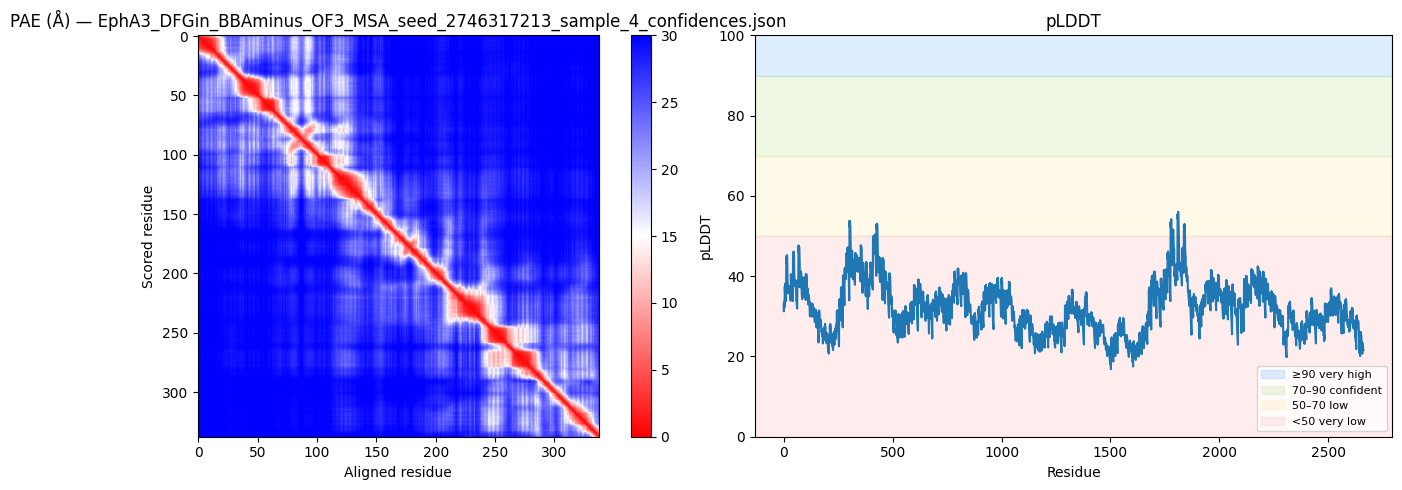

In [ ]:
#@title 9. PAE plot for best sample  { display-mode: "form" }

import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

output_dir = pathlib.Path(jobname) / "of3_output"
sample_files = sorted([f for f in output_dir.rglob("*_confidences.json")
                       if "aggregated" not in f.name])
if not sample_files:
    raise FileNotFoundError("No confidence JSONs found.")

# Pick the highest-pLDDT sample
def mean_plddt(cf):
    with open(cf) as f:
        d = json.load(f)
    plddt = d.get("plddt") or d.get("residue_plddts") or d.get("atom_plddts") or []
    return sum(plddt) / max(len(plddt), 1)

best = max(sample_files, key=mean_plddt)
with open(best) as f:
    d = json.load(f)

pae = d.get("predicted_aligned_error") or d.get("pae") or d.get("aligned_confidence_probs")
plddt = d.get("plddt") or d.get("residue_plddts") or []

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
if pae is not None:
    pae = np.asarray(pae)
    if pae.ndim == 3:
        # collapse aligned_confidence_probs → expected PAE
        bin_centers = np.linspace(0.5, 31.5, pae.shape[-1])
        pae = (pae * bin_centers).sum(-1)
    im = axs[0].imshow(pae, cmap="bwr_r", vmin=0, vmax=30)
    axs[0].set_title(f"PAE (Å) — {best.name}")
    axs[0].set_xlabel("Aligned residue"); axs[0].set_ylabel("Scored residue")
    plt.colorbar(im, ax=axs[0], fraction=0.046)
else:
    axs[0].text(0.5, 0.5, "no PAE in confidence JSON", ha="center", va="center")
    axs[0].set_axis_off()

if plddt:
    axs[1].plot(plddt, lw=1.5)
    axs[1].axhspan(90, 100, color="#1f8eff", alpha=0.15, label="≥90 very high")
    axs[1].axhspan(70, 90,  color="#92d050", alpha=0.15, label="70–90 confident")
    axs[1].axhspan(50, 70,  color="#ffd966", alpha=0.15, label="50–70 low")
    axs[1].axhspan(0,  50,  color="#ff8a8a", alpha=0.15, label="<50 very low")
    axs[1].set_xlabel("Residue"); axs[1].set_ylabel("pLDDT")
    axs[1].set_ylim(0, 100)
    axs[1].set_title("pLDDT")
    axs[1].legend(loc="lower right", fontsize=8)
else:
    axs[1].text(0.5, 0.5, "no pLDDT in confidence JSON", ha="center", va="center")
    axs[1].set_axis_off()

plt.tight_layout(); plt.show()


In [ ]:
#@title 10. Package + download results

import shutil, pathlib
result_zip = pathlib.Path(f"{jobname}.result.zip")
if result_zip.exists():
    result_zip.unlink()
shutil.make_archive(jobname + ".result", "zip", root_dir=jobname)
print(f"Archive: {result_zip}  ({result_zip.stat().st_size/1e6:.1f} MB)")

# Direct-download (Colab only)
try:
    from google.colab import files
    files.download(str(result_zip))
except Exception as e:
    print(f"(Colab direct download not available: {e})")

# Optional Drive upload
if save_to_google_drive:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=True)
        dest = pathlib.Path("/content/drive/MyDrive") / result_zip.name
        shutil.copy(result_zip, dest)
        print(f"Copied to {dest}")
    except Exception as e:
        print(f"Drive copy failed: {e}")


Archive: EphA3_DFGin_BBAminus_OF3_MSA.result.zip  (5.9 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>